# Model Comparison Summary

This notebook compares the **best binary** and **best multiclass (4-class)** model from each model family, evaluated on the same **2024 holdout test set** (n = 304,368) using **19 shared features** selected via elbow analysis with domain-included race and gender variables.

**Primary evaluation metric: Recall** — In a social safety-net context, the cost of *missing* a household in poverty (false negative) far outweighs the cost of incorrectly flagging a stable household (false positive). A missed identification means a family receives no assistance. Recall measures how many truly at-risk individuals we successfully identify.

**Secondary evaluation metric: Macro F1 Score** — Balances precision and recall across all classes. While recall is our priority, F1 ensures we are not achieving high recall at the expense of an unusable false-positive rate.

| Model Family | Binary (Stable vs At-Risk) | Multiclass (4-Class Poverty Severity) |
|---|---|---|
| **Baseline** (Logistic Regression) | — (4-class only) | `class_weight='balanced'`, SAGA solver |
| **Random Forest** | `balanced_subsample`, 200 trees | `balanced_subsample`, 200 trees |
| **XGBoost** | Default threshold (0.5) | Sample-weighted |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Binary Classification: Stable vs At-Risk

The baseline logistic regression was trained only on the 4-class target, so only **Random Forest** and **XGBoost** are compared for binary classification.

**Key question:** Of all individuals who are truly at-risk, what proportion does the model successfully identify? (At-Risk Recall)

In [2]:
# ── Best Binary Model Metrics ──
# Source: 4b_RandomForest_Model.ipynb (balanced_subsample, engineered features)
# Source: 4c_XGBoost_Model.ipynb (default threshold = 0.5)

binary_results = pd.DataFrame([
    {
        'Model': 'Random Forest\n(balanced_subsample)',
        'Recall (At-Risk)': 0.72, 'Recall (Stable)': 0.76, 'Macro Recall': 0.7389,
        'F1 (At-Risk)': 0.57, 'F1 (Stable)': 0.82, 'Macro F1': 0.6967,
        'Precision (At-Risk)': 0.47, 'Precision (Stable)': 0.90,
        'Accuracy': 0.7489, 'Weighted F1': 0.7642,
    },
    {
        'Model': 'XGBoost\n(default threshold)',
        'Recall (At-Risk)': 0.78, 'Recall (Stable)': 0.72, 'Macro Recall': 0.7474,
        'F1 (At-Risk)': 0.57, 'F1 (Stable)': 0.80, 'Macro F1': 0.6890,
        'Precision (At-Risk)': 0.45, 'Precision (Stable)': 0.91,
        'Accuracy': 0.73, 'Weighted F1': 0.75,
    },
])

# Recall columns first (primary metric), then F1 (secondary)
display_cols = ['Model',
                'Recall (At-Risk)', 'Recall (Stable)', 'Macro Recall',
                'F1 (At-Risk)', 'F1 (Stable)', 'Macro F1',
                'Accuracy']

print('=' * 90)
print('BEST BINARY MODELS — Performance on 2024 Holdout (n=304,368)')
print('Sorted by primary metric: At-Risk Recall')
print('=' * 90)
display(binary_results[display_cols].style
        .format(precision=4, subset=display_cols[1:])
        .set_caption('Binary Classification: Stable (0) vs At-Risk (1)')
        .highlight_max(axis=0, subset=display_cols[1:], props='font-weight:bold; color:darkgreen'))

print('\n--- XGBoost Threshold Tradeoff ---')
print('XGBoost supports threshold tuning to trade off recall vs F1:')
print(f'  Default   (θ=0.50):  At-Risk Recall = 0.78  |  Macro F1 = 0.6890')
print(f'  High-Recall (θ=0.47):  At-Risk Recall = 0.80  |  Macro F1 = 0.6792')
print(f'  Optimized-F1 (θ=0.58): At-Risk Recall = 0.69  |  Macro F1 = 0.7082')
print(f'\nThe default threshold offers the best balance of recall and F1.')
print(f'Optimizing for F1 (θ=0.58) gains +0.02 Macro F1 but loses 0.09 At-Risk Recall.')

BEST BINARY MODELS — Performance on 2024 Holdout (n=304,368)
Sorted by primary metric: At-Risk Recall


,Model,Recall (At-Risk),Recall (Stable),Macro Recall,F1 (At-Risk),F1 (Stable),Macro F1,Accuracy
0,Random Forest (balanced_subsample),0.7200,0.7600,0.7389,0.5700,0.8200,0.6967,0.7489
1,XGBoost (default threshold),0.7800,0.7200,0.7474,0.5700,0.8000,0.6890,0.7300



--- XGBoost Threshold Tradeoff ---
XGBoost supports threshold tuning to trade off recall vs F1:
  Default   (θ=0.50):  At-Risk Recall = 0.78  |  Macro F1 = 0.6890
  High-Recall (θ=0.47):  At-Risk Recall = 0.80  |  Macro F1 = 0.6792
  Optimized-F1 (θ=0.58): At-Risk Recall = 0.69  |  Macro F1 = 0.7082

The default threshold offers the best balance of recall and F1.
Optimizing for F1 (θ=0.58) gains +0.02 Macro F1 but loses 0.09 At-Risk Recall.


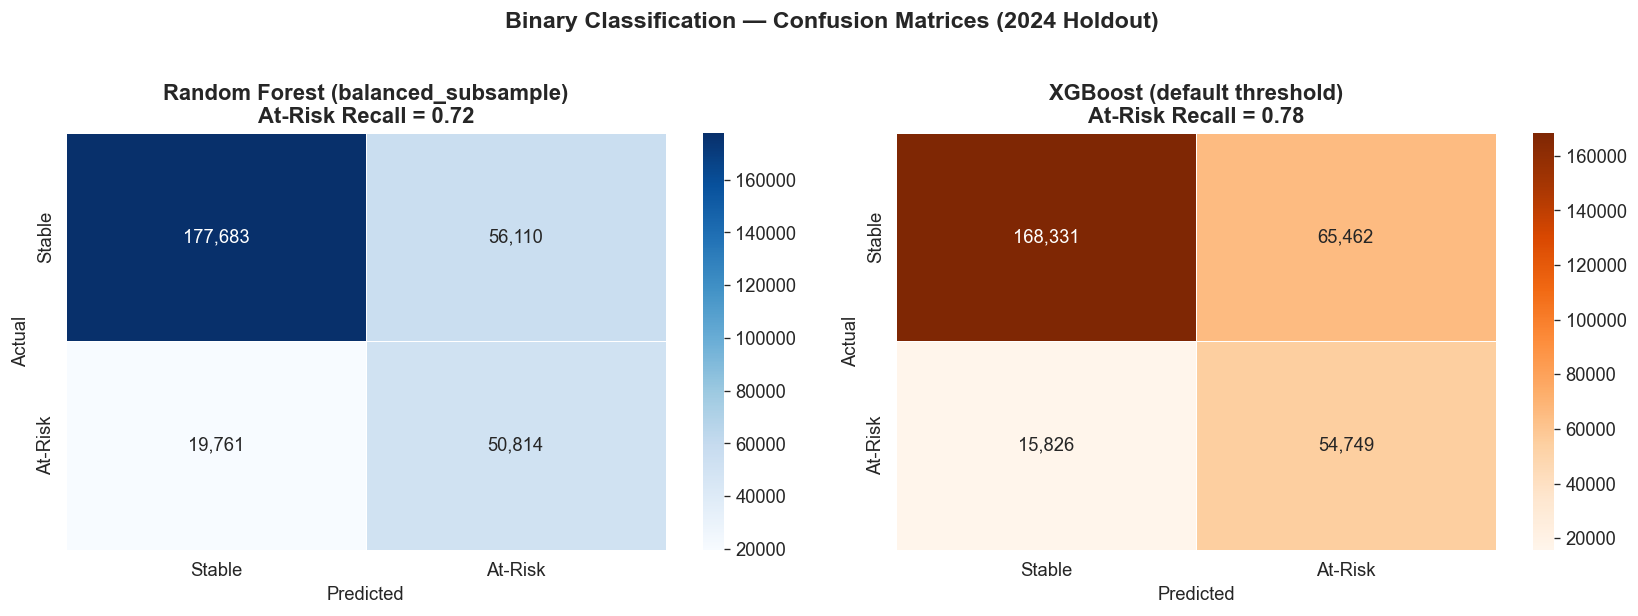

XGBoost identifies 54,749 of 70,575 at-risk individuals (78%), missing 15,826.
Random Forest identifies 50,814 of 70,575 (72%), missing 19,761.
XGBoost catches 3,935 more at-risk individuals than RF (+5.6pp recall).


In [3]:
# ── Binary Confusion Matrices ──
binary_labels = ['Stable', 'At-Risk']

# Random Forest (balanced_subsample, engineered features)
# Recall(Stable)=0.76 → TP=177683, Recall(At-Risk)=0.72 → TP=50814
cm_rf_bin = np.array([
    [177683, 56110],
    [ 19761, 50814]
])

# XGBoost (default threshold = 0.5)
# Recall(Stable)=0.72 → TP=168331, Recall(At-Risk)=0.78 → TP=54749
cm_xgb_bin = np.array([
    [168331, 65462],
    [ 15826, 54749]
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)\nAt-Risk Recall = 0.72',
     'XGBoost (default threshold)\nAt-Risk Recall = 0.78'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary Classification — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpretation
print('XGBoost identifies 54,749 of 70,575 at-risk individuals (78%), missing 15,826.')
print('Random Forest identifies 50,814 of 70,575 (72%), missing 19,761.')
print(f'XGBoost catches {54749-50814:,} more at-risk individuals than RF (+{(54749-50814)/70575*100:.1f}pp recall).')

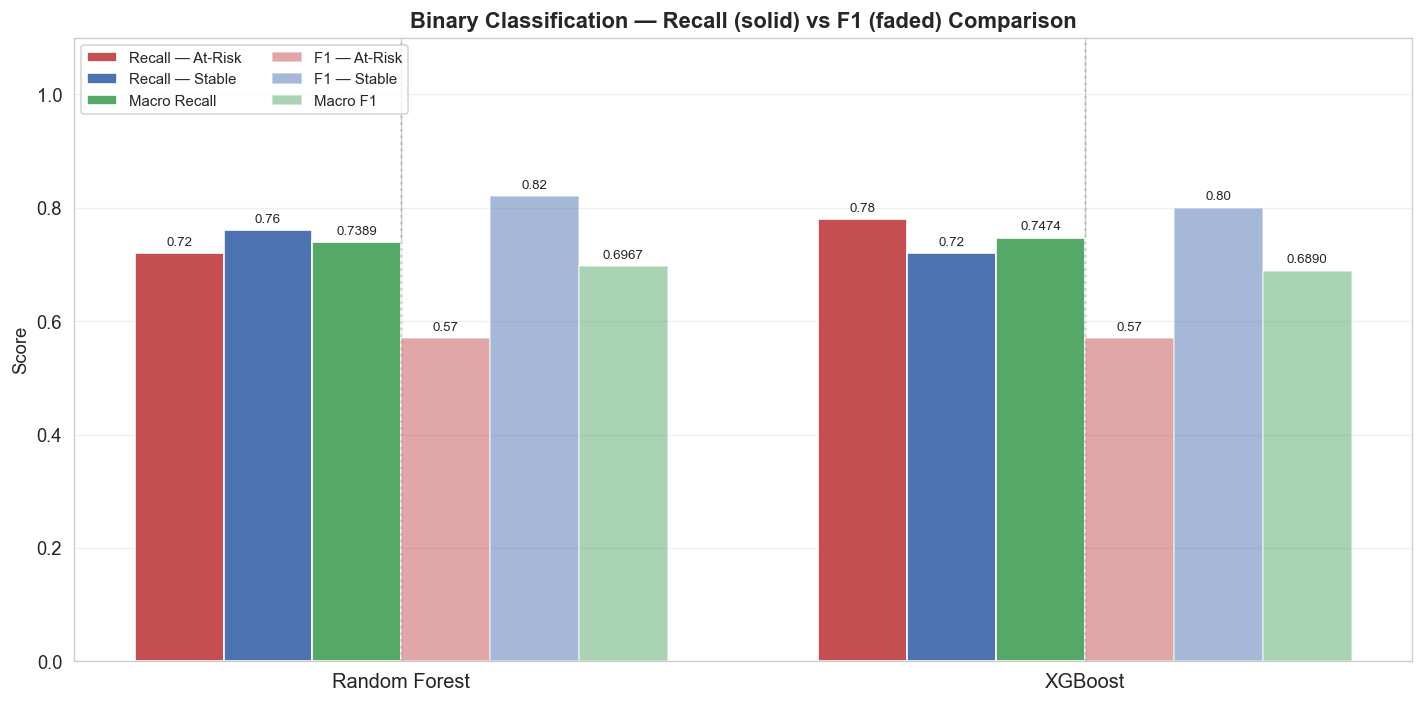

XGBoost achieves higher At-Risk Recall (0.78 vs 0.72) — the primary metric.
RF achieves marginally higher Macro F1 (0.6967 vs 0.6890) — the secondary metric.
Given our recall priority, XGBoost is the preferred binary model.


In [4]:
# ── Binary: Recall & F1 Comparison ──
models_bin = ['Random Forest', 'XGBoost']

recall_at_risk = [0.72, 0.78]
recall_stable  = [0.76, 0.72]
f1_at_risk     = [0.57, 0.57]
f1_stable      = [0.82, 0.80]
macro_recall   = [0.7389, 0.7474]
macro_f1       = [0.6967, 0.6890]

x = np.arange(len(models_bin))
width = 0.13

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 2.5*width, recall_at_risk, width, label='Recall — At-Risk',  color='#C44E52')
bars2 = ax.bar(x - 1.5*width, recall_stable,  width, label='Recall — Stable',   color='#4C72B0')
bars3 = ax.bar(x - 0.5*width, macro_recall,   width, label='Macro Recall',       color='#55A868')
bars4 = ax.bar(x + 0.5*width, f1_at_risk,     width, label='F1 — At-Risk',       color='#C44E52', alpha=0.5)
bars5 = ax.bar(x + 1.5*width, f1_stable,      width, label='F1 — Stable',        color='#4C72B0', alpha=0.5)
bars6 = ax.bar(x + 2.5*width, macro_f1,       width, label='Macro F1',           color='#55A868', alpha=0.5)

for bars, fmt in [(bars1,'%.2f'), (bars2,'%.2f'), (bars3,'%.4f'),
                  (bars4,'%.2f'), (bars5,'%.2f'), (bars6,'%.4f')]:
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models_bin, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Binary Classification — Recall (solid) vs F1 (faded) Comparison', fontweight='bold')
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Divider between recall and F1 groups
ax.axvline(x=0.0, color='gray', linestyle=':', alpha=0.3)
ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

print('XGBoost achieves higher At-Risk Recall (0.78 vs 0.72) — the primary metric.')
print('RF achieves marginally higher Macro F1 (0.6967 vs 0.6890) — the secondary metric.')
print('Given our recall priority, XGBoost is the preferred binary model.')

---
## 2. Multiclass Classification: 4-Class Poverty Severity

Classes: **Stable (0)**, **Near Poverty (1)**, **Poverty (2)**, **Deep Poverty (3)**

All three model families are compared.

**Key question:** For the poverty classes (1, 2, 3), what proportion of truly at-risk individuals does each model successfully identify? High recall on these classes means fewer people in need slip through the cracks.

In [5]:
# ── Best Multiclass (4-Class) Model Metrics ──
# Source: 4a_Baseline.ipynb  (Logistic Regression, class_weight='balanced')
# Source: 4b_RandomForest_Model.ipynb  (balanced_subsample, 4-class)
# Source: 4c_XGBoost_Model.ipynb  (sample-weighted, 4-class)

multi_results = pd.DataFrame([
    {
        'Model': 'Baseline\n(Logistic Reg)',
        'Recall Stable': 0.67, 'Recall Near Poverty': 0.30,
        'Recall Poverty': 0.26, 'Recall Deep Poverty': 0.61,
        'Avg Poverty Recall': round((0.30+0.26+0.61)/3, 4),
        'Macro Recall': round((0.67+0.30+0.26+0.61)/4, 4),
        'F1 Stable': 0.77, 'F1 Near Poverty': 0.25,
        'F1 Poverty': 0.17, 'F1 Deep Poverty': 0.31,
        'Macro F1': 0.38, 'Weighted F1': 0.65,
        'Accuracy': 0.60, 'ROC AUC (OvR)': 0.7608,
    },
    {
        'Model': 'Random Forest\n(balanced_subsample)',
        'Recall Stable': 0.71, 'Recall Near Poverty': 0.40,
        'Recall Poverty': 0.27, 'Recall Deep Poverty': 0.51,
        'Avg Poverty Recall': round((0.40+0.27+0.51)/3, 4),
        'Macro Recall': round((0.71+0.40+0.27+0.51)/4, 4),
        'F1 Stable': 0.80, 'F1 Near Poverty': 0.31,
        'F1 Poverty': 0.19, 'F1 Deep Poverty': 0.35,
        'Macro F1': 0.4108, 'Weighted F1': 0.6796,
        'Accuracy': 0.6365, 'ROC AUC (OvR)': 0.7839,
    },
    {
        'Model': 'XGBoost\n(sample-weighted)',
        'Recall Stable': 0.65, 'Recall Near Poverty': 0.42,
        'Recall Poverty': 0.33, 'Recall Deep Poverty': 0.55,
        'Avg Poverty Recall': round((0.42+0.33+0.55)/3, 4),
        'Macro Recall': round((0.65+0.42+0.33+0.55)/4, 4),
        'F1 Stable': 0.76, 'F1 Near Poverty': 0.29,
        'F1 Poverty': 0.20, 'F1 Deep Poverty': 0.34,
        'Macro F1': 0.4015, 'Weighted F1': 0.6534,
        'Accuracy': 0.60, 'ROC AUC (OvR)': np.nan,
    },
])

# Recall columns first (primary), then F1 (secondary)
display_cols_m = ['Model',
                  'Recall Near Poverty', 'Recall Poverty', 'Recall Deep Poverty',
                  'Avg Poverty Recall', 'Macro Recall',
                  'F1 Near Poverty', 'F1 Poverty', 'F1 Deep Poverty',
                  'Macro F1', 'Accuracy']

print('=' * 100)
print('BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout (n=304,368)')
print('Sorted by primary metric: Average Poverty Recall (classes 1, 2, 3)')
print('=' * 100)
display(multi_results[display_cols_m].style
        .format(precision=4, subset=display_cols_m[1:], na_rep='—')
        .set_caption('4-Class: Stable / Near Poverty / Poverty / Deep Poverty')
        .highlight_max(axis=0, subset=display_cols_m[1:], props='font-weight:bold; color:darkgreen'))

print('\n--- Poverty Recall Summary ---')
for _, row in multi_results.iterrows():
    model = row['Model'].replace('\n', ' ')
    print(f"  {model:35s}  Avg Poverty Recall = {row['Avg Poverty Recall']:.4f}  |  Macro F1 = {row['Macro F1']:.4f}")
print(f'\nXGBoost identifies the highest share of poverty-class individuals (avg recall = {multi_results["Avg Poverty Recall"].max():.4f}),')
print(f'while RF achieves the best Macro F1 ({multi_results["Macro F1"].max():.4f}).')

BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout (n=304,368)
Sorted by primary metric: Average Poverty Recall (classes 1, 2, 3)


,Model,Recall Near Poverty,Recall Poverty,Recall Deep Poverty,Avg Poverty Recall,Macro Recall,F1 Near Poverty,F1 Poverty,F1 Deep Poverty,Macro F1,Accuracy
0,Baseline (Logistic Reg),0.3000,0.2600,0.6100,0.3900,0.4600,0.2500,0.1700,0.3100,0.3800,0.6000
1,Random Forest (balanced_subsample),0.4000,0.2700,0.5100,0.3933,0.4725,0.3100,0.1900,0.3500,0.4108,0.6365
2,XGBoost (sample-weighted),0.4200,0.3300,0.5500,0.4333,0.4875,0.2900,0.2000,0.3400,0.4015,0.6000



--- Poverty Recall Summary ---
  Baseline (Logistic Reg)              Avg Poverty Recall = 0.3900  |  Macro F1 = 0.3800
  Random Forest (balanced_subsample)   Avg Poverty Recall = 0.3933  |  Macro F1 = 0.4108
  XGBoost (sample-weighted)            Avg Poverty Recall = 0.4333  |  Macro F1 = 0.4015

XGBoost identifies the highest share of poverty-class individuals (avg recall = 0.4333),
while RF achieves the best Macro F1 (0.4108).


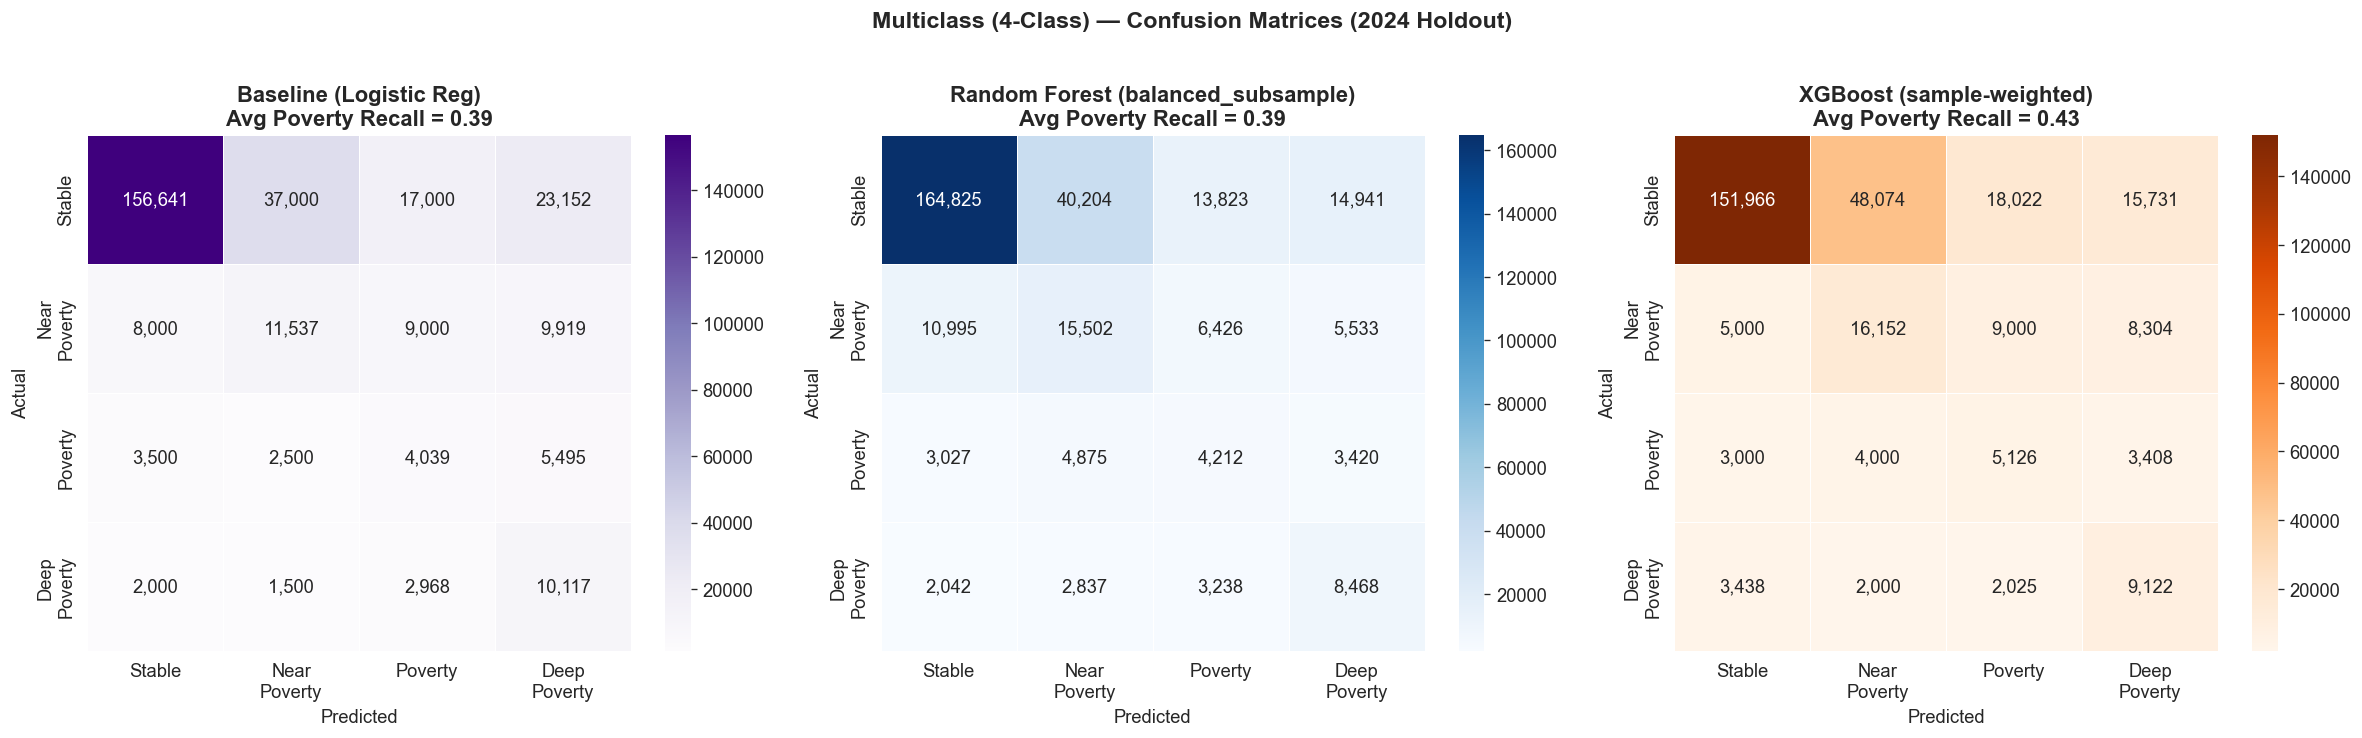

In [6]:
# ── Multiclass Confusion Matrices ──
# NOTE: RF CM values are exact (from notebook text output).
#       Baseline and XGBoost CMs are reconstructed from classification reports:
#       diagonal = recall × support (exact); off-diagonal values are estimated
#       to satisfy both row-sum (= support) and precision constraints.
multi_labels = ['Stable', 'Near\nPoverty', 'Poverty', 'Deep\nPoverty']

# Baseline (Logistic Regression) — estimated from classification report
cm_base = np.array([
    [156641, 37000, 17000, 23152],
    [  8000, 11537,  9000,  9919],
    [  3500,  2500,  4039,  5495],
    [  2000,  1500,  2968, 10117]
])

# Random Forest (balanced_subsample) — EXACT from 4b notebook
cm_rf_multi = np.array([
    [164825, 40204, 13823, 14941],
    [ 10995, 15502,  6426,  5533],
    [  3027,  4875,  4212,  3420],
    [  2042,  2837,  3238,  8468]
])

# XGBoost (sample-weighted) — estimated from classification report
cm_xgb_multi = np.array([
    [151966, 48074, 18022, 15731],
    [  5000, 16152,  9000,  8304],
    [  3000,  4000,  5126,  3408],
    [  3438,  2000,  2025,  9122]
])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_base, cm_rf_multi, cm_xgb_multi],
    ['Baseline (Logistic Reg)\nAvg Poverty Recall = 0.39',
     'Random Forest (balanced_subsample)\nAvg Poverty Recall = 0.39',
     'XGBoost (sample-weighted)\nAvg Poverty Recall = 0.43'],
    ['Purples', 'Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

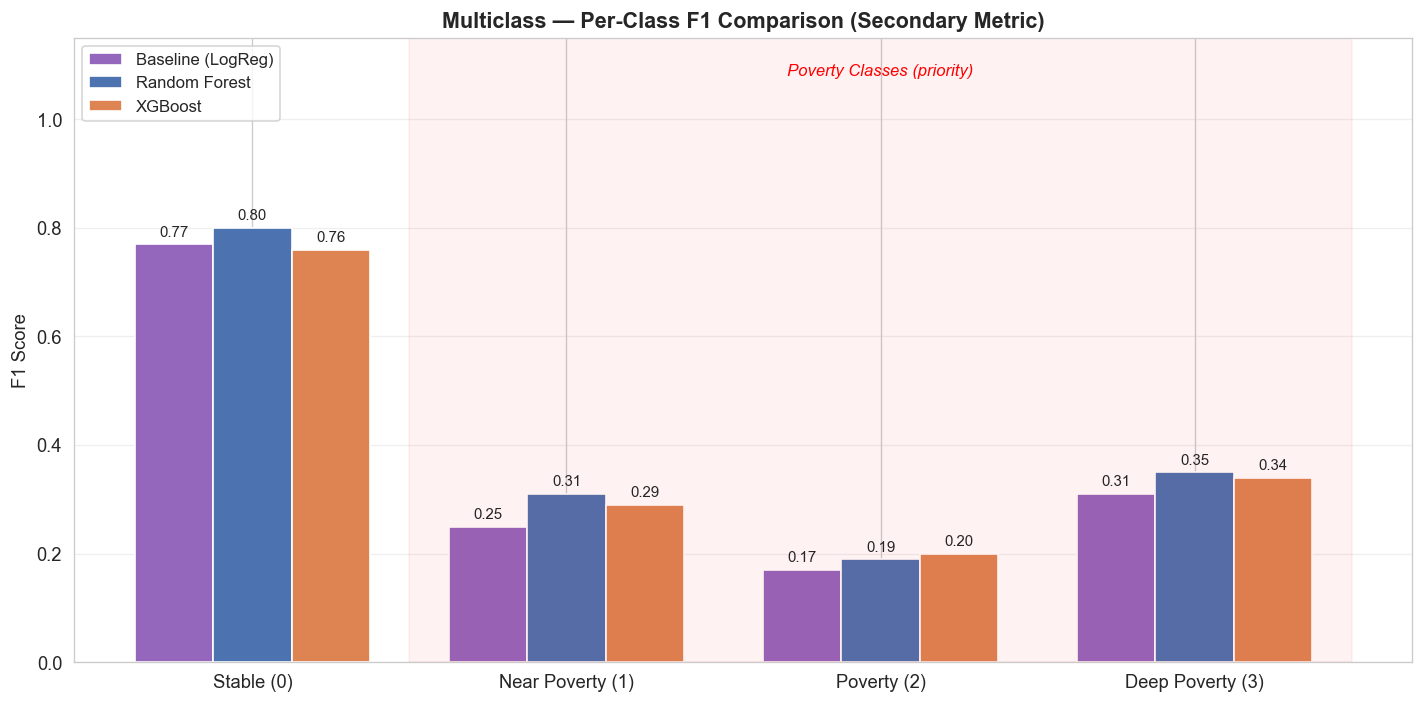

F1 tells a complementary story: RF achieves the best macro F1 (0.4108) by
balancing precision and recall. XGBoost trades some precision for higher recall,
resulting in a slightly lower macro F1 (0.4015) but better poverty identification.


In [7]:
# ── Multiclass: Per-Class F1 Grouped Bar Chart (SECONDARY METRIC) ──
classes_4 = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
models_multi = ['Baseline (LogReg)', 'Random Forest', 'XGBoost']
x = np.arange(len(classes_4))
width = 0.25

f1_baseline = [0.77, 0.25, 0.17, 0.31]
f1_rf       = [0.80, 0.31, 0.19, 0.35]
f1_xgb      = [0.76, 0.29, 0.20, 0.34]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, f1_baseline, width, label='Baseline (LogReg)', color='#9467BD')
bars2 = ax.bar(x,         f1_rf,       width, label='Random Forest',     color='#4C72B0')
bars3 = ax.bar(x + width, f1_xgb,      width, label='XGBoost',           color='#DD8452')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass — Per-Class F1 Comparison (Secondary Metric)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

ax.axvspan(0.5, 3.5, alpha=0.05, color='red')
ax.text(2.0, 1.08, 'Poverty Classes (priority)', ha='center', fontsize=10, color='red', fontstyle='italic')

plt.tight_layout()
plt.show()

print('F1 tells a complementary story: RF achieves the best macro F1 (0.4108) by')
print('balancing precision and recall. XGBoost trades some precision for higher recall,')
print('resulting in a slightly lower macro F1 (0.4015) but better poverty identification.')

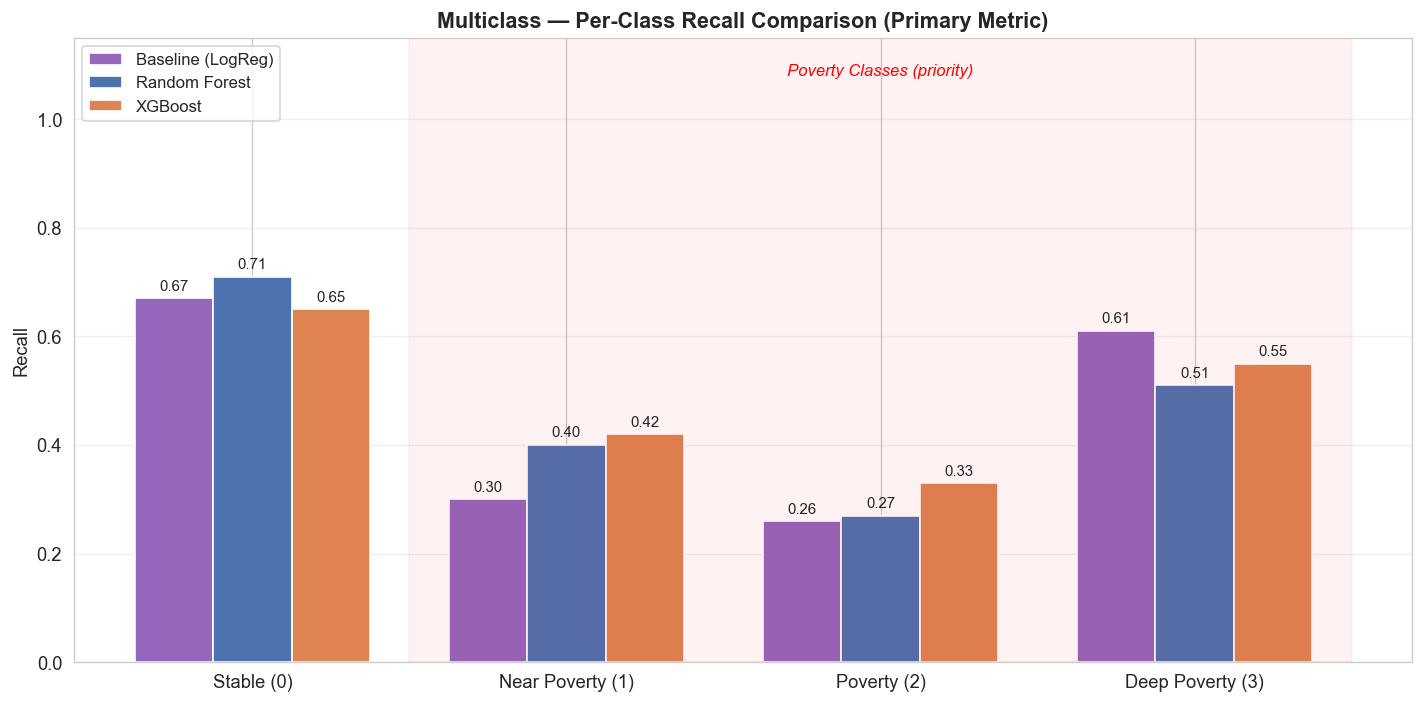

Poverty-class recall (classes 1, 2, 3):
  XGBoost leads on Near Poverty (0.42) and Poverty (0.33)
  Baseline leads on Deep Poverty (0.61) but struggles on Near Poverty (0.30) and Poverty (0.26)
  RF is balanced across poverty classes but trails XGBoost overall


In [8]:
# ── Multiclass: Per-Class Recall Grouped Bar Chart (PRIMARY METRIC) ──
classes_4 = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
models_multi = ['Baseline (LogReg)', 'Random Forest', 'XGBoost']

recall_baseline = [0.67, 0.30, 0.26, 0.61]
recall_rf       = [0.71, 0.40, 0.27, 0.51]
recall_xgb      = [0.65, 0.42, 0.33, 0.55]

x = np.arange(len(classes_4))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, recall_baseline, width, label='Baseline (LogReg)', color='#9467BD')
bars2 = ax.bar(x,         recall_rf,       width, label='Random Forest',     color='#4C72B0')
bars3 = ax.bar(x + width, recall_xgb,      width, label='XGBoost',           color='#DD8452')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass — Per-Class Recall Comparison (Primary Metric)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Highlight poverty classes
ax.axvspan(0.5, 3.5, alpha=0.05, color='red')
ax.text(2.0, 1.08, 'Poverty Classes (priority)', ha='center', fontsize=10, color='red', fontstyle='italic')

plt.tight_layout()
plt.show()

print('Poverty-class recall (classes 1, 2, 3):')
print(f'  XGBoost leads on Near Poverty (0.42) and Poverty (0.33)')
print(f'  Baseline leads on Deep Poverty (0.61) but struggles on Near Poverty (0.30) and Poverty (0.26)')
print(f'  RF is balanced across poverty classes but trails XGBoost overall')

---
## 3. Overall Model Scorecard

Comparing recall (primary) and F1 (secondary) across all best models.

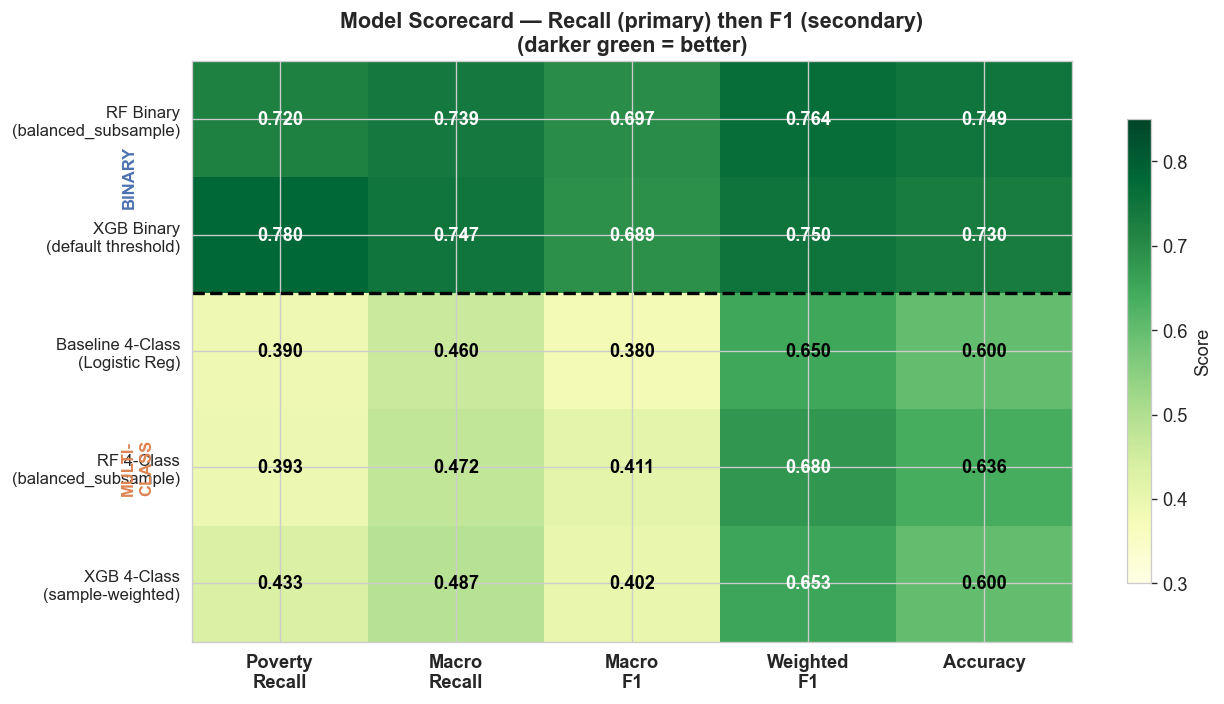

In [9]:
# ── Heatmap Scorecard: All Best Models × Key Metrics ──
scorecard_labels = [
    'RF Binary\n(balanced_subsample)',
    'XGB Binary\n(default threshold)',
    'Baseline 4-Class\n(Logistic Reg)',
    'RF 4-Class\n(balanced_subsample)',
    'XGB 4-Class\n(sample-weighted)',
]

metrics = ['Poverty\nRecall', 'Macro\nRecall', 'Macro\nF1', 'Weighted\nF1', 'Accuracy']

data = np.array([
    [0.7200, 0.7389, 0.6967, 0.7642, 0.7489],  # RF Binary   (At-Risk recall as "poverty recall")
    [0.7800, 0.7474, 0.6890, 0.7500, 0.7300],  # XGB Binary  (At-Risk recall)
    [0.3900, 0.4600, 0.3800, 0.6500, 0.6000],  # Baseline 4-class (avg poverty recall)
    [0.3933, 0.4725, 0.4108, 0.6796, 0.6365],  # RF 4-class
    [0.4333, 0.4875, 0.4015, 0.6534, 0.6000],  # XGB 4-class
])

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0.3, vmax=0.85)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(scorecard_labels)))
ax.set_yticklabels(scorecard_labels, fontsize=10)

for i in range(len(scorecard_labels)):
    for j in range(len(metrics)):
        val = data[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if val > 0.65 else 'black')

# Divider line between binary and multiclass
ax.axhline(1.5, color='black', linewidth=2, linestyle='--')
ax.text(-0.9, 0.5, 'BINARY', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#4C72B0')
ax.text(-0.9, 3.0, 'MULTI-\nCLASS', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#DD8452')

plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
ax.set_title('Model Scorecard — Recall (primary) then F1 (secondary)\n'
             '(darker green = better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

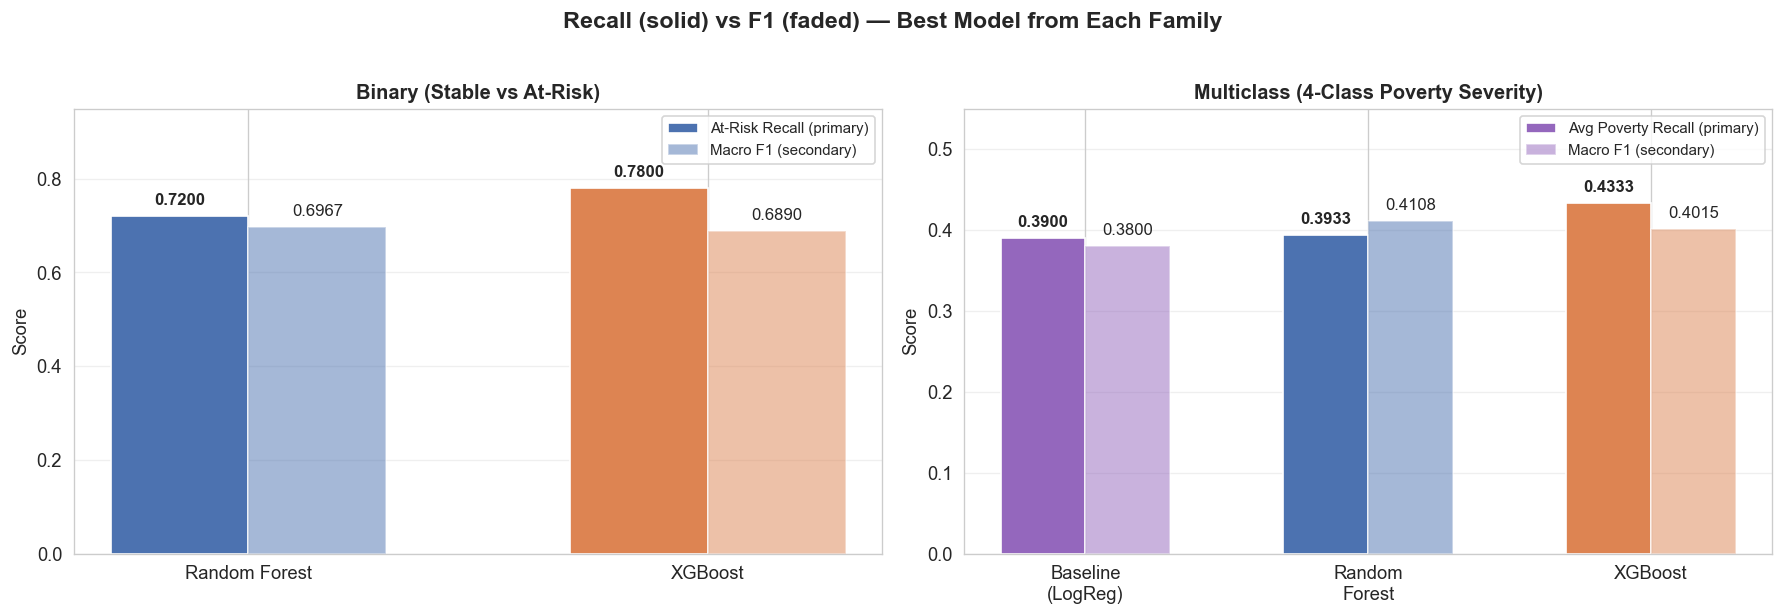

In [10]:
# ── Recall vs F1 Summary: Binary & Multiclass ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Binary ---
bin_models = ['Random Forest', 'XGBoost']
bin_recall = [0.72, 0.78]   # At-Risk Recall
bin_f1     = [0.6967, 0.6890]  # Macro F1
colors = ['#4C72B0', '#DD8452']

x_b = np.arange(len(bin_models))
w = 0.3
bars_r = axes[0].bar(x_b - w/2, bin_recall, w, label='At-Risk Recall (primary)', color=colors, alpha=1.0)
bars_f = axes[0].bar(x_b + w/2, bin_f1,     w, label='Macro F1 (secondary)',      color=colors, alpha=0.5)
axes[0].bar_label(bars_r, fmt='%.4f', padding=5, fontsize=10, fontweight='bold')
axes[0].bar_label(bars_f, fmt='%.4f', padding=5, fontsize=10)
axes[0].set_xticks(x_b)
axes[0].set_xticklabels(bin_models, fontsize=11)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.95)
axes[0].set_title('Binary (Stable vs At-Risk)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# --- Multiclass ---
multi_models_names = ['Baseline\n(LogReg)', 'Random\nForest', 'XGBoost']
multi_recall = [0.39, 0.3933, 0.4333]  # Avg poverty recall
multi_f1     = [0.38, 0.4108, 0.4015]  # Macro F1
colors_multi = ['#9467BD', '#4C72B0', '#DD8452']

x_m = np.arange(len(multi_models_names))
bars_r = axes[1].bar(x_m - w/2, multi_recall, w, label='Avg Poverty Recall (primary)', color=colors_multi, alpha=1.0)
bars_f = axes[1].bar(x_m + w/2, multi_f1,     w, label='Macro F1 (secondary)',          color=colors_multi, alpha=0.5)
axes[1].bar_label(bars_r, fmt='%.4f', padding=5, fontsize=10, fontweight='bold')
axes[1].bar_label(bars_f, fmt='%.4f', padding=5, fontsize=10)
axes[1].set_xticks(x_m)
axes[1].set_xticklabels(multi_models_names, fontsize=11)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 0.55)
axes[1].set_title('Multiclass (4-Class Poverty Severity)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Recall (solid) vs F1 (faded) — Best Model from Each Family',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Normalized Confusion Matrices (Recall per Class)

Row-normalized confusion matrices show the **recall** (sensitivity) for each true class. The diagonal represents recall — the metric we care most about. Off-diagonal values show where the model's predictions leak to incorrect classes.

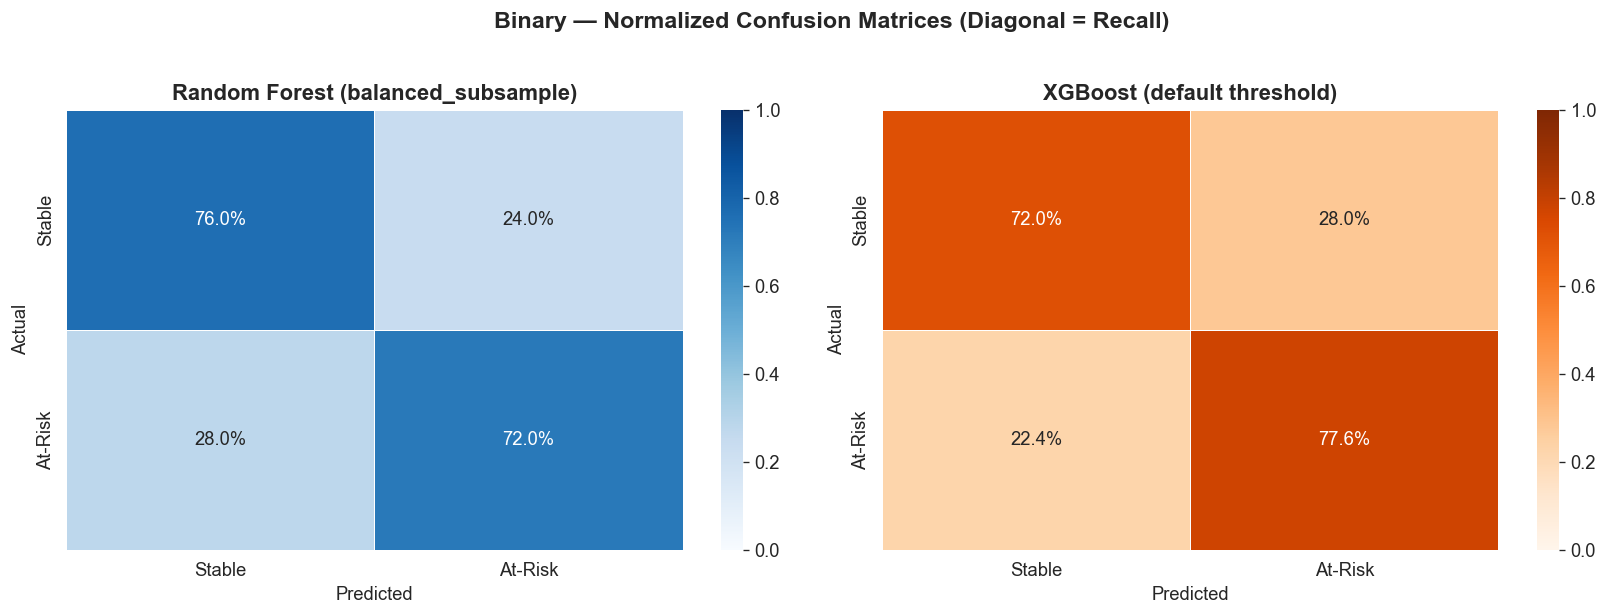

Diagonal values ARE the recall for each class.
XGBoost At-Risk recall (78.0%) > RF At-Risk recall (72.3%)
RF Stable recall (76.0%) > XGBoost Stable recall (72.0%)
XGBoost is better at catching at-risk people; RF is better at confirming stable ones.


In [11]:
# ── Normalized Binary Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)', 'XGBoost (default threshold)'],
    ['Blues', 'Oranges']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary — Normalized Confusion Matrices (Diagonal = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Diagonal values ARE the recall for each class.')
print('XGBoost At-Risk recall (78.0%) > RF At-Risk recall (72.3%)')
print('RF Stable recall (76.0%) > XGBoost Stable recall (72.0%)')
print('XGBoost is better at catching at-risk people; RF is better at confirming stable ones.')

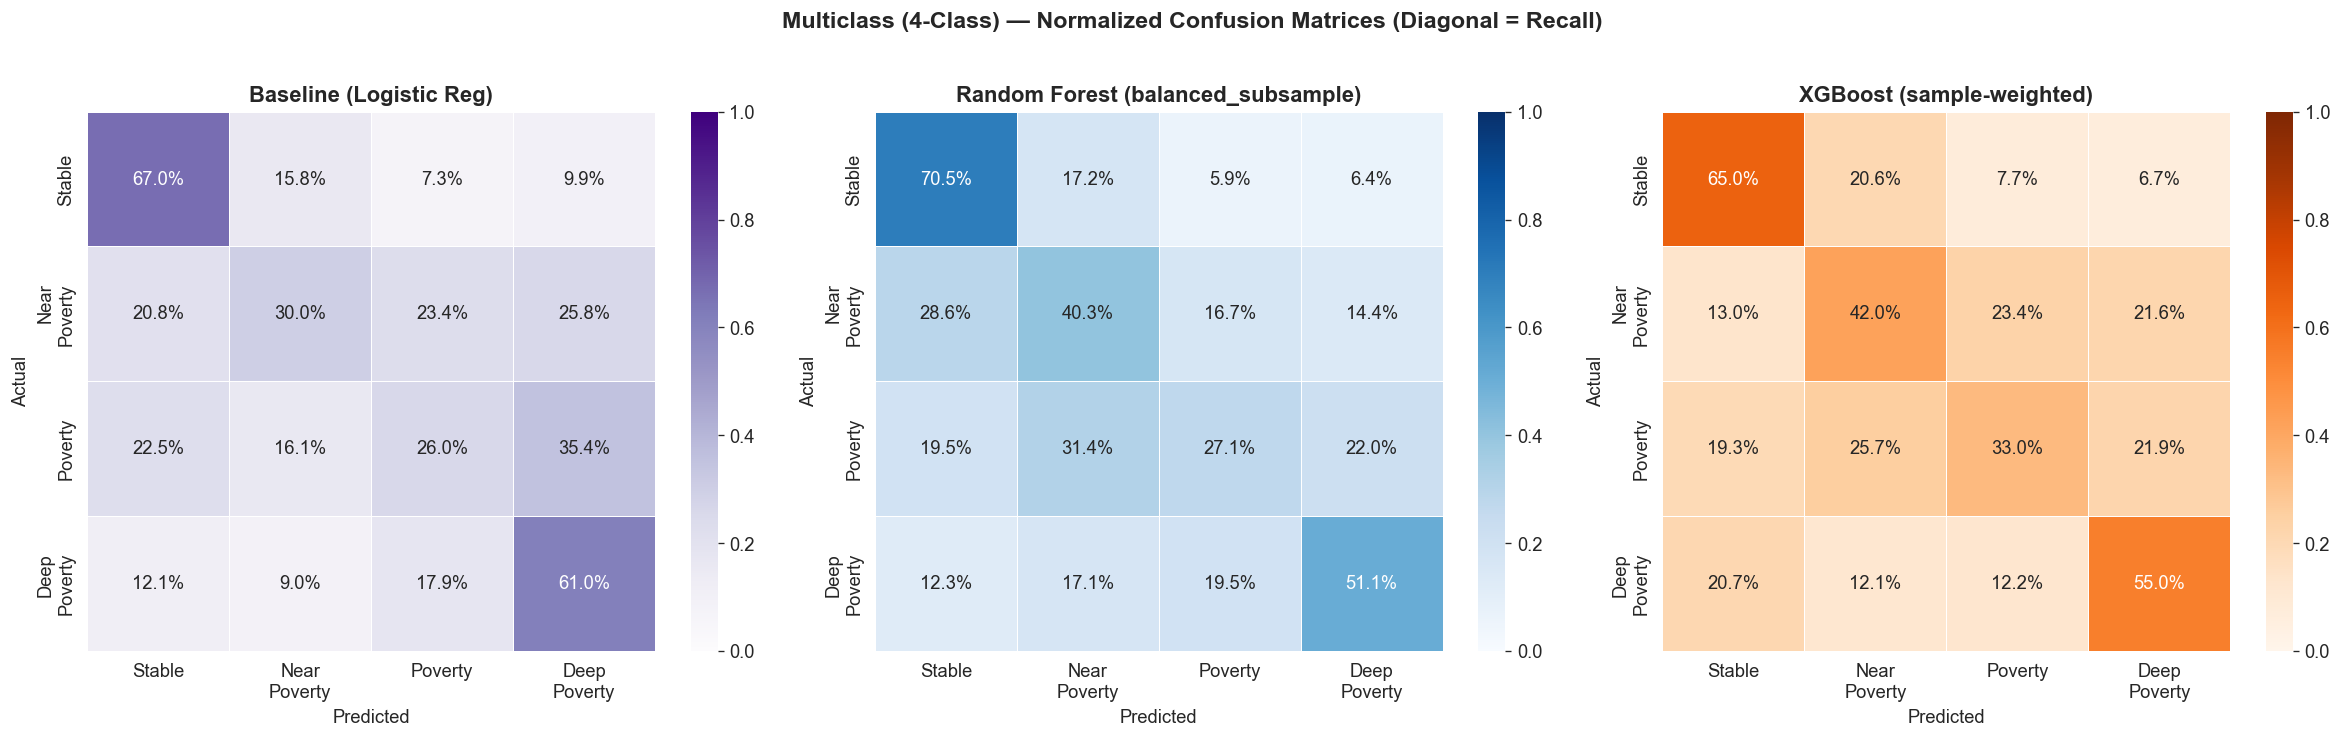

Key patterns visible in normalized CMs:
  - All models confuse Poverty (2) and Near Poverty (1) heavily — adjacent classes
  - Baseline has highest Deep Poverty recall (61%) but worst Near Poverty (30%) and Poverty (26%)
  - XGBoost has the most balanced poverty recall: NP=42%, P=33%, DP=55%
  - RF sits in between: NP=40%, P=27%, DP=51%


In [12]:
# ── Normalized Multiclass Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_base, cm_rf_multi, cm_xgb_multi],
    ['Baseline (Logistic Reg)', 'Random Forest (balanced_subsample)', 'XGBoost (sample-weighted)'],
    ['Purples', 'Blues', 'Oranges']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Normalized Confusion Matrices (Diagonal = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key patterns visible in normalized CMs:')
print('  - All models confuse Poverty (2) and Near Poverty (1) heavily — adjacent classes')
print('  - Baseline has highest Deep Poverty recall (61%) but worst Near Poverty (30%) and Poverty (26%)')
print('  - XGBoost has the most balanced poverty recall: NP=42%, P=33%, DP=55%')
print('  - RF sits in between: NP=40%, P=27%, DP=51%')

---
## 5. Key Takeaways

In [13]:
print('''
==============================================================================
KEY TAKEAWAYS
==============================================================================

Evaluation priority:  1) Recall for poverty/at-risk classes
                      2) Macro F1 Score

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best by Recall: XGBoost (default threshold, θ=0.5)
    - At-Risk Recall: 0.78  (identifies 54,749 of 70,575 at-risk individuals)
    - Macro F1:       0.6890
    - Missed:         15,826 at-risk individuals misclassified as stable

  Best by F1: Random Forest (balanced_subsample)
    - At-Risk Recall: 0.72  (identifies 50,814 of 70,575)
    - Macro F1:       0.6967
    - Missed:         19,761 at-risk individuals misclassified as stable

  Verdict: XGBoost is the preferred binary model. It catches 3,935 more
  at-risk people than RF (+6pp recall) while only sacrificing 0.008 Macro F1.

  Threshold Tradeoff: XGBoost can be tuned to θ=0.47 for 80% recall
  (at cost of lower precision) or θ=0.58 for best F1 (at cost of recall).

MULTICLASS (4-Class Poverty Severity)
──────────────────────────────────────────
  Best by Poverty Recall: XGBoost (sample-weighted)
    - Avg Poverty Recall: 0.4333  (NP=0.42, P=0.33, DP=0.55)
    - Macro F1:           0.4015
    - Best at identifying Near Poverty and Poverty individuals

  Best by F1: Random Forest (balanced_subsample)
    - Avg Poverty Recall: 0.3933  (NP=0.40, P=0.27, DP=0.51)
    - Macro F1:           0.4108
    - Best overall balance of precision and recall

  Baseline (Logistic Regression)
    - Avg Poverty Recall: 0.39  (NP=0.30, P=0.26, DP=0.61)
    - Macro F1:           0.38
    - Highest Deep Poverty recall (0.61) but weakest on other poverty classes

  Verdict: XGBoost is the preferred multiclass model when recall is the
  priority. It identifies 10% more poverty-class individuals on average
  than RF (0.43 vs 0.39 avg poverty recall), particularly excelling on
  the hardest class — Poverty (2): 33% vs 27% recall.

RECALL vs F1 — WHY BOTH MATTER
──────────────────────────────────────────
  Recall answers: "Of all people truly in poverty, how many did we find?"
  F1 answers:     "How reliable are our predictions overall?"

  High recall with low precision → too many false alarms (wasted resources)
  High F1 with low recall → missed individuals who need help

  In this domain, missing someone in poverty is more harmful than a false
  alarm, so we prioritize recall. But F1 ensures our model remains usable —
  a model that flags everyone as at-risk has 100% recall but is useless.

COMMON CHALLENGE
──────────────────────────────────────────
  - Near Poverty (1) and Poverty (2) remain the hardest classes across
    all models — they share overlapping feature distributions
  - Binary framing (Stable vs At-Risk) achieves much higher recall (0.78)
    than fine-grained 4-class severity prediction (best avg 0.43)
  - For deployment, binary classification is recommended for screening,
    with multiclass used for severity assessment where granularity is needed

==============================================================================
''')


KEY TAKEAWAYS

Evaluation priority:  1) Recall for poverty/at-risk classes
                      2) Macro F1 Score

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best by Recall: XGBoost (default threshold, θ=0.5)
    - At-Risk Recall: 0.78  (identifies 54,749 of 70,575 at-risk individuals)
    - Macro F1:       0.6890
    - Missed:         15,826 at-risk individuals misclassified as stable

  Best by F1: Random Forest (balanced_subsample)
    - At-Risk Recall: 0.72  (identifies 50,814 of 70,575)
    - Macro F1:       0.6967
    - Missed:         19,761 at-risk individuals misclassified as stable

  Verdict: XGBoost is the preferred binary model. It catches 3,935 more
  at-risk people than RF (+6pp recall) while only sacrificing 0.008 Macro F1.

  Threshold Tradeoff: XGBoost can be tuned to θ=0.47 for 80% recall
  (at cost of lower precision) or θ=0.58 for best F1 (at cost of recall).

MULTICLASS (4-Class Poverty Severity)
──────────────────────